# Apex Legends EWC Finals Analysis

- Player data cleaning
- Efficiency metrics
- Role classification
- Custom performance and MVP scores
- Overperformance analysis
- Team summary analysis
- Weapons data cleaning and effectiveness analysis
- Exporting cleaned outputs


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid")

## Load and clean player data

In [2]:
player_file = "../data/Apex Y5 EWC Finals Players stats.csv"

df = pd.read_csv(player_file, encoding="latin1")

print("Original shape:", df.shape)
df.head()

Original shape: (60, 22)


,Team,Player,Games,Kills,Assists,Kill Participation%,Knocks,Times knocked,Dmg dealt,Dmg taken,Dmg diff,Dmg/kill,Ring dmg,Rez.,Rspn.,K/D,KA/D,Surv. time,Top 10%,T10?T5%,T5?T1%,Unnamed: 21
0,TS<,PanicApex,9,10,5,71.4,16,12,"5,104","6,291","-1,187",510.40,384,2,0,1.11,1.67,2h 9m 35s,22.20%,50%,100%,NaN
1,GEN,Z1CKKY,9,8,11,55.9,12,9,"3,859","4,325",-466,482.38,274,3,4,1.00,2.38,2h 42m 22s,66.70%,66.70%,25%,NaN
2,E36,ILY,9,12,12,80.0,13,12,"4,376","4,933",-557,364.67,262,2,2,1.00,2.00,2h 36m 18s,66.70%,0%,0%,NaN
3,WOL,CrazyCong,9,5,16,60.0,7,9,"3,538","5,218","-1,680",707.60,129,11,2,0.63,2.63,2h 39m 36s,55.60%,80%,25%,NaN
4,ALL,Effect,9,16,11,77.1,21,11,"6,687","6,317",370,417.94,242,1,2,1.60,2.70,2h 24m 15s,33.30%,0%,0%,NaN


In [3]:
df.columns = df.columns.str.replace("\xa0", "", regex=False).str.strip()
df = df.drop(columns=["Unnamed: 21"], errors="ignore")

numeric_str_cols = ["Dmg dealt", "Dmg taken", "Dmg diff", "Ring dmg"]

for col in numeric_str_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Cleaned columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

df.head()

Cleaned columns:
['Team', 'Player', 'Games', 'Kills', 'Assists', 'Kill Participation%', 'Knocks', 'Times knocked', 'Dmg dealt', 'Dmg taken', 'Dmg diff', 'Dmg/kill', 'Ring dmg', 'Rez.', 'Rspn.', 'K/D', 'KA/D', 'Surv. time', 'Top 10%', 'T10?T5%', 'T5?T1%']

Missing values:
Team                   0
Player                 0
Games                  0
Kills                  0
Assists                0
Kill Participation%    0
Knocks                 0
Times knocked          0
Dmg dealt              0
Dmg taken              0
Dmg diff               0
Dmg/kill               0
Ring dmg               0
Rez.                   0
Rspn.                  0
K/D                    0
KA/D                   0
Surv. time             0
Top 10%                0
T10?T5%                0
T5?T1%                 0
dtype: int64


,Team,Player,Games,Kills,Assists,Kill Participation%,Knocks,Times knocked,Dmg dealt,Dmg taken,Dmg diff,Dmg/kill,Ring dmg,Rez.,Rspn.,K/D,KA/D,Surv. time,Top 10%,T10?T5%,T5?T1%
0,TS<,PanicApex,9,10,5,71.4,16,12,5104,6291,-1187,510.40,384,2,0,1.11,1.67,2h 9m 35s,22.20%,50%,100%
1,GEN,Z1CKKY,9,8,11,55.9,12,9,3859,4325,-466,482.38,274,3,4,1.00,2.38,2h 42m 22s,66.70%,66.70%,25%
2,E36,ILY,9,12,12,80.0,13,12,4376,4933,-557,364.67,262,2,2,1.00,2.00,2h 36m 18s,66.70%,0%,0%
3,WOL,CrazyCong,9,5,16,60.0,7,9,3538,5218,-1680,707.60,129,11,2,0.63,2.63,2h 39m 36s,55.60%,80%,25%
4,ALL,Effect,9,16,11,77.1,21,11,6687,6317,370,417.94,242,1,2,1.60,2.70,2h 24m 15s,33.30%,0%,0%


In [4]:
df.describe(include="all")

,Team,Player,Games,Kills,Assists,Kill Participation%,Knocks,Times knocked,Dmg dealt,Dmg taken,Dmg diff,Dmg/kill,Ring dmg,Rez.,Rspn.,K/D,KA/D,Surv. time,Top 10%,T10?T5%,T5?T1%
count,60,60,60.0,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60,60,60,60
unique,21,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59,7,11,5
top,GEN,PanicApex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2h 42m 22s,55.60%,0%,0%
freq,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,15,15,39
mean,NaN,NaN,9.0,8.933333,9.116667,67.375000,12.066667,11.483333,5468.133333,5482.350000,-14.216667,804.119833,352.933333,2.583333,0.916667,0.981667,1.988333,NaN,NaN,NaN,NaN
std,NaN,NaN,0.0,4.722347,5.175207,12.617994,5.590145,2.151008,1738.699392,1058.840393,1185.023365,606.186813,235.564441,3.325768,1.168683,0.592227,1.115120,NaN,NaN,NaN,NaN
min,NaN,NaN,9.0,0.000000,1.000000,42.900000,1.000000,8.000000,2733.000000,3397.000000,-2509.000000,364.670000,80.000000,0.000000,0.000000,0.000000,0.600000,NaN,NaN,NaN,NaN
25%,NaN,NaN,9.0,5.000000,5.000000,55.975000,8.750000,10.000000,4063.250000,4726.250000,-873.250000,504.360000,173.750000,1.000000,0.000000,0.560000,1.110000,NaN,NaN,NaN,NaN
50%,NaN,NaN,9.0,8.000000,8.000000,66.300000,12.000000,11.000000,5215.000000,5495.000000,-148.000000,624.300000,280.500000,2.000000,0.500000,0.845000,1.800000,NaN,NaN,NaN,NaN
75%,NaN,NaN,9.0,12.250000,12.000000,75.225000,16.000000,13.000000,6549.750000,6297.500000,774.750000,816.850000,482.250000,3.000000,2.000000,1.337500,2.412500,NaN,NaN,NaN,NaN


## Build player metrics

In [5]:
df["Damage per Kill"] = df["Dmg dealt"] / df["Kills"].replace(0, pd.NA)
df["Assist Ratio"] = df["Assists"] / (df["Kills"] + 1)
df["Damage Efficiency"] = df["Dmg diff"] / (df["Dmg taken"] + 1)

df[["Player", "Team", "Damage per Kill", "Assist Ratio", "Damage Efficiency"]].head()

,Player,Team,Damage per Kill,Assist Ratio,Damage Efficiency
0,PanicApex,TS<,510.4,0.454545,-0.188652
1,Z1CKKY,GEN,482.375,1.222222,-0.107721
2,ILY,E36,364.666667,0.923077,-0.112890
3,CrazyCong,WOL,707.6,2.666667,-0.321901
4,Effect,ALL,417.9375,0.647059,0.058563


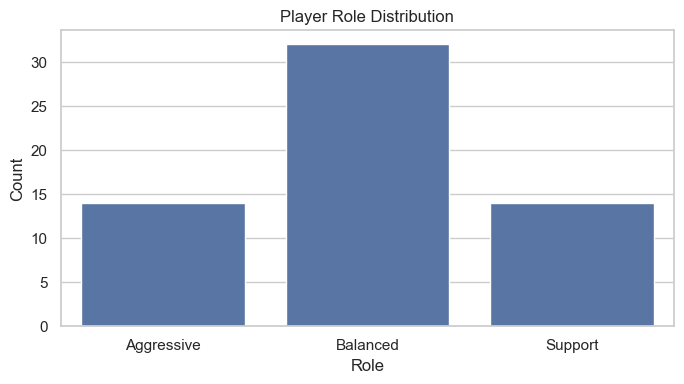

In [6]:
def classify_role(row):
    if row["Kills"] > row["Assists"] * 1.5:
        return "Aggressive"
    elif row["Assists"] > row["Kills"] * 1.5:
        return "Support"
    return "Balanced"

df["Role"] = df.apply(classify_role, axis=1)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Role")
plt.title("Player Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
df["Performance Score"] = (
    df["Kills"] * 3
    + df["Assists"] * 2
    + df["Knocks"] * 1.5
    + df["Dmg diff"] * 0.01
    + df["Kill Participation%"] * 0.5
    + df["K/D"] * 5
)

df["MVP Score"] = (
    df["Kills"] * 4
    + df["Assists"] * 2
    + df["Knocks"] * 2
    + df["Dmg diff"] * 0.02
    + df["K/D"] * 6
    - df["Times knocked"] * 1.5
)

df[["Player", "Team", "Performance Score", "MVP Score"]].head()

,Player,Team,Performance Score,MVP Score
0,PanicApex,TS<,93.38,46.92
1,Z1CKKY,GEN,92.29,61.18
2,ILY,E36,118.93,74.86
3,CrazyCong,WOL,73.85,22.68
4,Effect,ALL,151.75,128.50


In [8]:
df["Expected Kills"] = df["Dmg dealt"] / df["Dmg dealt"].mean() * df["Kills"].mean()
df["Overperformance"] = df["Kills"] - df["Expected Kills"]

top_over = df.sort_values("Overperformance", ascending=False).head(10)
top_over[["Player", "Team", "Overperformance", "Kills", "Dmg dealt"]]

,Player,Team,Overperformance,Kills,Dmg dealt
32,sauceror,ROC,6.465680,16,5836
4,Effect,ALL,5.075394,16,6687
2,ILY,E36,4.850894,12,4376
51,Unlucky,ALL,4.469118,15,6446
28,Donut,WOL,4.450196,19,8906
53,Cinap,E36,4.419424,11,4028
54,QQ,VKG,4.092073,17,7901
47,ImperialHal,FLCN,3.868084,16,7426
50,ASIA,GEN,3.495769,17,8266
16,Kassa,VKG,3.324059,16,7759


## Top player views

In [9]:
top_players = df.sort_values("MVP Score", ascending=False).head(10)

top_players[[
    "Player", "Team", "MVP Score", "Performance Score", "Kills", "Assists",
    "Knocks", "Dmg dealt", "Dmg diff", "K/D", "Role"
]]

,Player,Team,MVP Score,Performance Score,Kills,Assists,Knocks,Dmg dealt,Dmg diff,K/D,Role
32,sauceror,ROC,189.70,207.83,16,29,17,5836,1598,2.29,Support
40,Deeds,ROC,179.06,163.86,16,10,19,8899,2766,2.29,Aggressive
28,Donut,WOL,177.56,191.60,19,11,26,8906,2020,2.11,Aggressive
43,mclovin,NIP,168.28,169.37,13,16,18,9473,2882,1.44,Balanced
20,Genburten,100T,168.02,165.46,16,6,20,8538,2751,2.00,Aggressive
50,ASIA,GEN,148.08,155.49,17,6,23,8266,1569,1.70,Aggressive
54,QQ,VKG,146.56,173.59,17,17,22,7901,649,2.43,Balanced
18,Vaxlon,ROC,145.06,143.93,14,11,18,8500,1703,1.75,Balanced
47,ImperialHal,FLCN,142.58,167.79,16,13,20,7426,1049,1.60,Balanced
51,Unlucky,ALL,140.72,156.38,15,12,19,6446,1353,1.36,Balanced


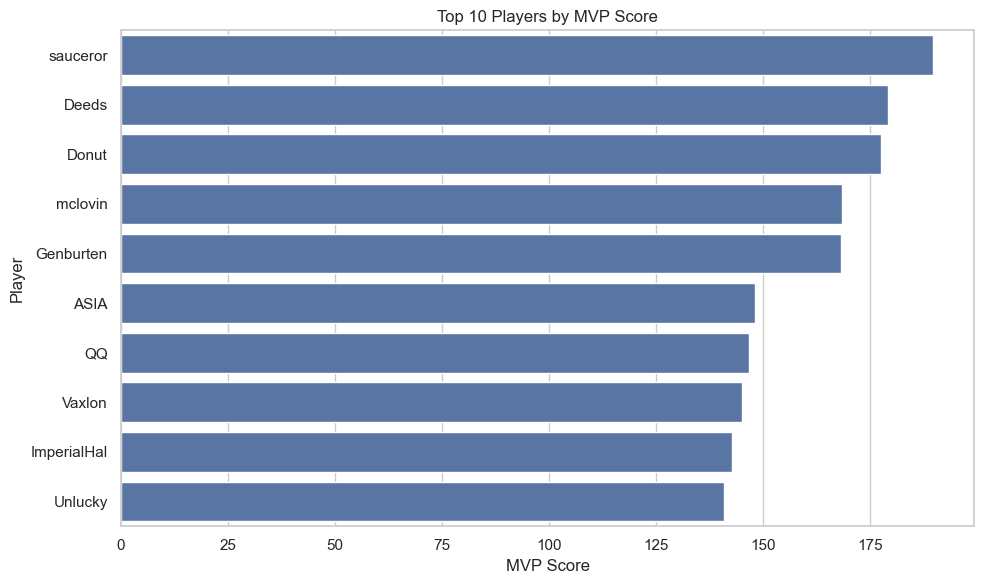

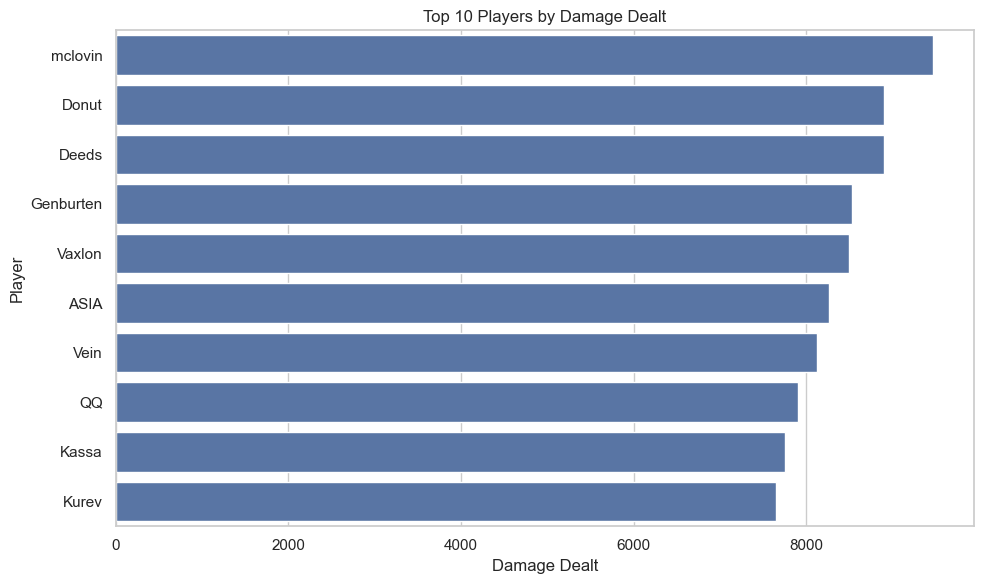

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_players, x="MVP Score", y="Player")
plt.title("Top 10 Players by MVP Score")
plt.xlabel("MVP Score")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

top_damage = df.sort_values("Dmg dealt", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_damage, x="Dmg dealt", y="Player")
plt.title("Top 10 Players by Damage Dealt")
plt.xlabel("Damage Dealt")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

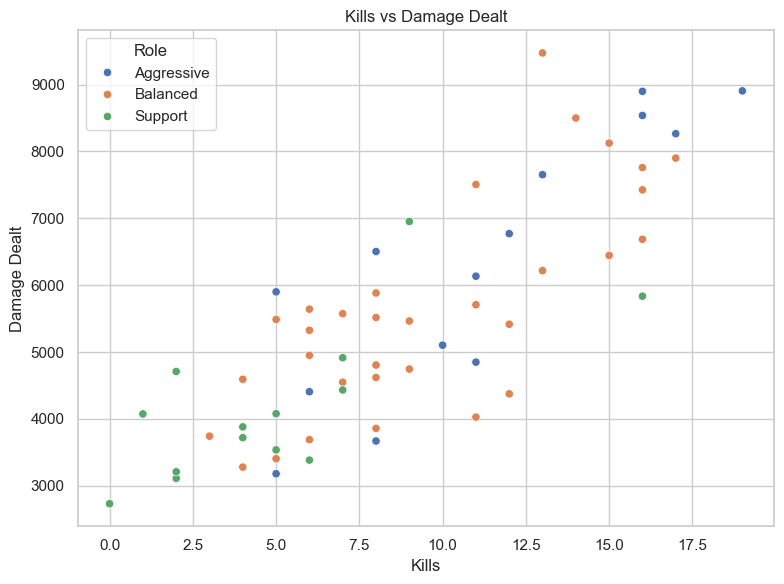

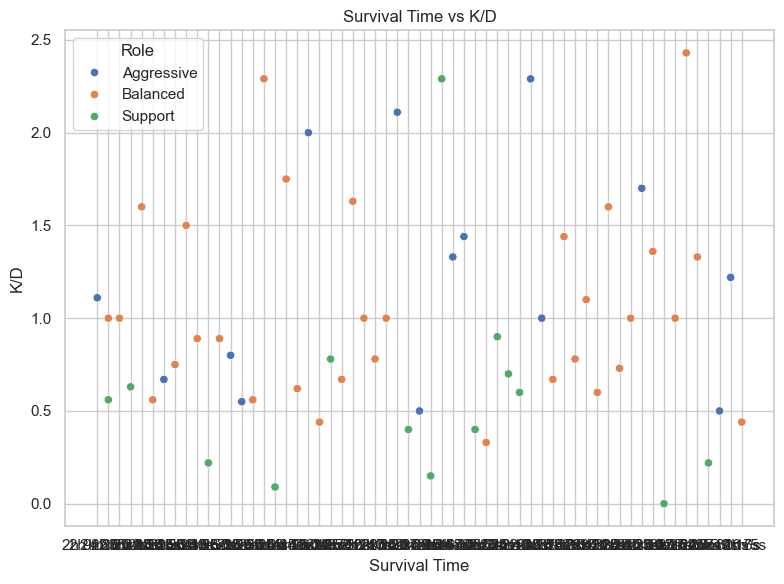

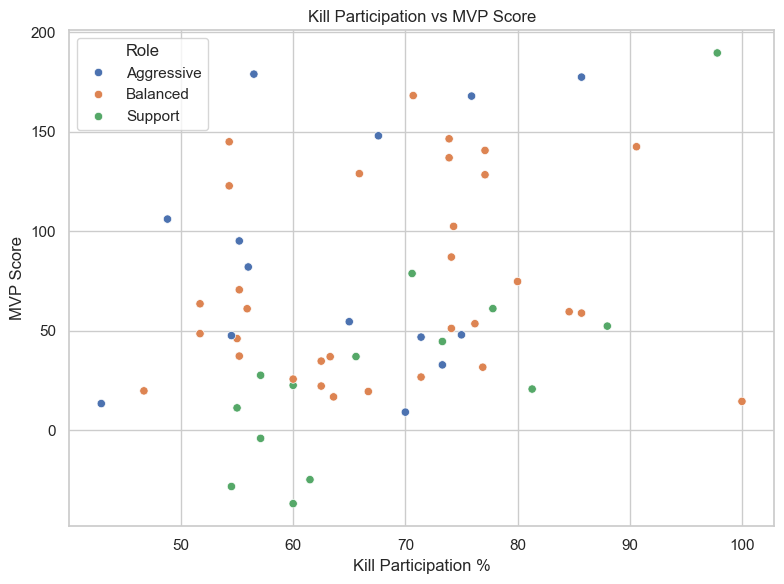

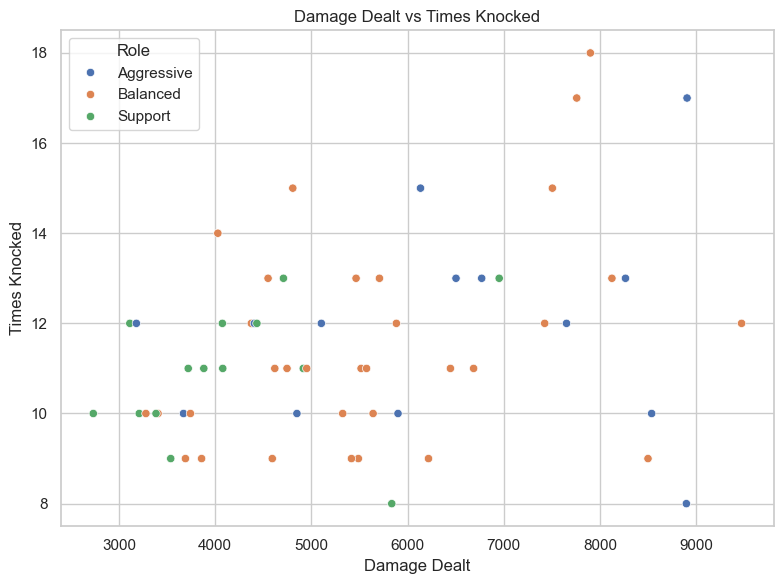

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Kills", y="Dmg dealt", hue="Role")
plt.title("Kills vs Damage Dealt")
plt.xlabel("Kills")
plt.ylabel("Damage Dealt")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Surv. time", y="K/D", hue="Role")
plt.title("Survival Time vs K/D")
plt.xlabel("Survival Time")
plt.ylabel("K/D")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Kill Participation%", y="MVP Score", hue="Role")
plt.title("Kill Participation vs MVP Score")
plt.xlabel("Kill Participation %")
plt.ylabel("MVP Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Dmg dealt", y="Times knocked", hue="Role")
plt.title("Damage Dealt vs Times Knocked")
plt.xlabel("Damage Dealt")
plt.ylabel("Times Knocked")
plt.tight_layout()
plt.show()

## Team analysis

In [12]:
team_summary = df.groupby("Team").agg({
    "Kills": "sum",
    "Assists": "sum",
    "Dmg dealt": "sum",
    "Dmg diff": "sum",
    "MVP Score": "mean",
    "K/D": "mean"
}).reset_index()

team_summary = team_summary.sort_values("MVP Score", ascending=False)
team_summary

,Team,Kills,Assists,Dmg dealt,Dmg diff,MVP Score,K/D
11,ROC,46,50,23235,6067,171.273333,2.110000
18,VKG,46,47,21878,2521,135.506667,2.116667
9,NIP,41,35,25251,4739,134.520000,1.460000
20,WOL,35,42,19950,963,100.933333,1.280000
1,ALL,35,39,16853,715,98.986667,1.120000
6,GEN,34,32,19078,1252,96.046667,1.200000
0,100T,29,23,19754,2683,93.446667,1.176667
10,NMSS,29,19,16138,825,67.773333,1.073333
3,FLCN,32,38,17213,-2346,67.346667,1.053333
12,RVL,27,34,15850,-1092,66.553333,1.000000


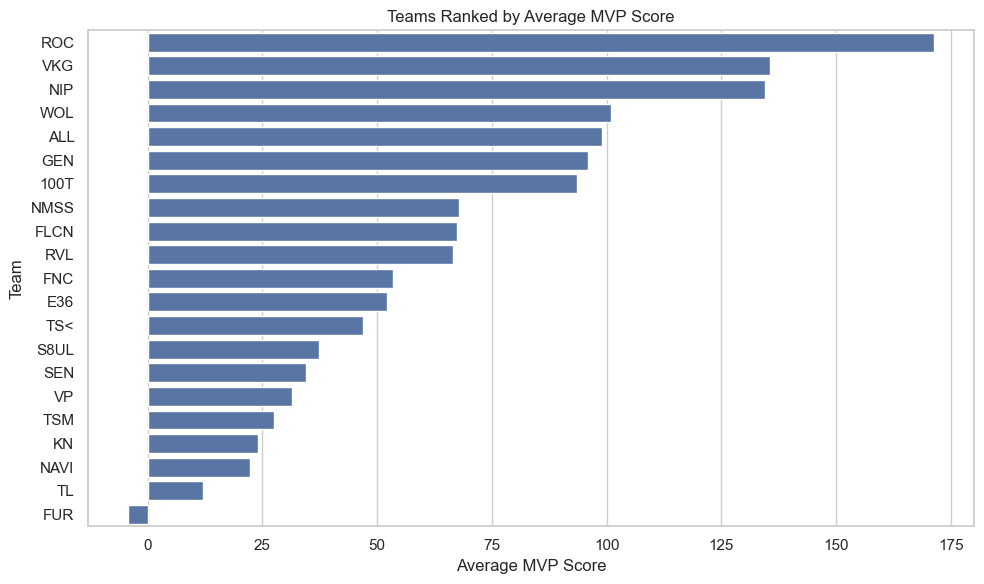

Role,Aggressive,Balanced,Support
Team,,,
100T,1,2,0
ALL,0,2,1
E36,0,2,1
FLCN,0,2,1
FNC,1,1,1
FUR,1,1,1
GEN,1,1,1
KN,1,2,0
NAVI,0,2,1


In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=team_summary, x="MVP Score", y="Team")
plt.title("Teams Ranked by Average MVP Score")
plt.xlabel("Average MVP Score")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

team_roles = df.groupby(["Team", "Role"]).size().unstack(fill_value=0)
team_roles

## Correlation analysis

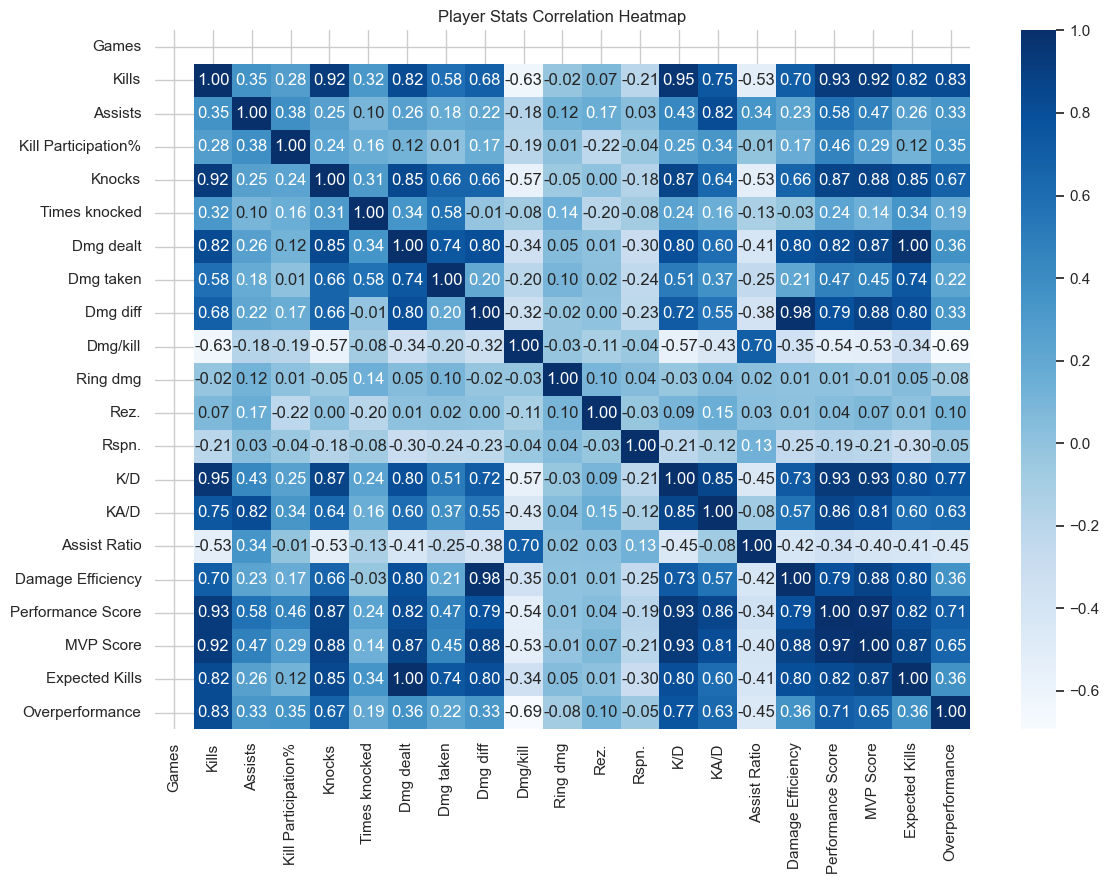

MVP Score              1.000000
Performance Score      0.974963
K/D                    0.933040
Kills                  0.922341
Damage Efficiency      0.878604
Knocks                 0.877167
Dmg diff               0.876004
Expected Kills         0.868775
Dmg dealt              0.868775
KA/D                   0.814468
Overperformance        0.654535
Assists                0.471521
Dmg taken              0.446200
Kill Participation%    0.291879
Times knocked          0.141205
Rez.                   0.073201
Ring dmg              -0.014337
Rspn.                 -0.206125
Assist Ratio          -0.403314
Dmg/kill              -0.526249
Games                       NaN
Name: MVP Score, dtype: float64

In [14]:
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Player Stats Correlation Heatmap")
plt.tight_layout()
plt.show()

df.corr(numeric_only=True)["MVP Score"].sort_values(ascending=False)

## Load and clean weapons data

In [15]:
weapons_file = "../data/Weapons Stats Summary.csv"

weapons = pd.read_csv(weapons_file, encoding="latin1")
weapons.columns = weapons.columns.str.replace("\xa0", "", regex=False).str.strip()

print("Weapons shape:", weapons.shape)
print(weapons.columns.tolist())
weapons.head()

Weapons shape: (33, 11)
['Weapon', 'Kills', 'Damage?', 'Knockdowns?', 'FWR%?', 'Shots?', 'Hits?', 'Accuracy?', 'Playtime?', 'Max kill dist.?', 'Max dmg dist.']


,Weapon,Kills,Damage?,Knockdowns?,FWR%?,Shots?,Hits?,Accuracy?,Playtime?,Max kill dist.?,Max dmg dist.
0,R-99 SMG,157,59234,324,62.67%,18642,4847,26%,10h 27m 24s,48.7,147.8
1,Devotion LMG,65,26041,135,65.53%,7090,1736,24.49%,3h 40m 5s,44.5,165.8
2,30-30 Repeater,41,69570,96,68.57%,8144,1305,16.02%,17h 59m 46s,209.8,363.8
3,G7 Scout,38,38629,87,76.99%,9373,1139,12.15%,11h 3m 32s,288.0,351.3
4,HAVOC Rifle,36,13485,68,61.26%,3904,716,18.34%,4h 19m 35s,70.3,162.9


In [16]:
weapons = weapons.dropna(axis=1, how="all")

for col in weapons.columns:
    if weapons[col].dtype == "object":
        cleaned = (
            weapons[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )
        converted = pd.to_numeric(cleaned, errors="coerce")
        if converted.notna().sum() >= max(1, len(weapons) // 2):
            weapons[col] = converted

print(weapons.dtypes)
weapons.head()

Weapon                 str
Kills                int64
Damage?              int64
Knockdowns?          int64
FWR%?                  str
Shots?                 str
Hits?                  str
Accuracy?              str
Playtime?              str
Max kill dist.?    float64
Max dmg dist.      float64
dtype: object


,Weapon,Kills,Damage?,Knockdowns?,FWR%?,Shots?,Hits?,Accuracy?,Playtime?,Max kill dist.?,Max dmg dist.
0,R-99 SMG,157,59234,324,62.67%,18642,4847,26%,10h 27m 24s,48.7,147.8
1,Devotion LMG,65,26041,135,65.53%,7090,1736,24.49%,3h 40m 5s,44.5,165.8
2,30-30 Repeater,41,69570,96,68.57%,8144,1305,16.02%,17h 59m 46s,209.8,363.8
3,G7 Scout,38,38629,87,76.99%,9373,1139,12.15%,11h 3m 32s,288.0,351.3
4,HAVOC Rifle,36,13485,68,61.26%,3904,716,18.34%,4h 19m 35s,70.3,162.9


## Weapons analysis

In [17]:
weapon_name_col = None
for candidate in ["Weapon", "Weapons", "Name"]:
    if candidate in weapons.columns:
        weapon_name_col = candidate
        break

if weapon_name_col is None:
    weapon_name_col = weapons.columns[0]

numeric_weapon_cols = weapons.select_dtypes(include="number").columns.tolist()
print("Weapon name column:", weapon_name_col)
print("Numeric weapon columns:", numeric_weapon_cols)

Weapon name column: Weapon
Numeric weapon columns: ['Kills', 'Damage?', 'Knockdowns?', 'Max kill dist.?', 'Max dmg dist.']


In [18]:
weapons = weapons.copy()

if len(numeric_weapon_cols) >= 3:
    base_cols = numeric_weapon_cols[:3]
    weapons["Weapon Effectiveness Score"] = weapons[base_cols[0]].fillna(0)
    weapons["Weapon Effectiveness Score"] += weapons[base_cols[1]].fillna(0) * 0.5
    weapons["Weapon Effectiveness Score"] += weapons[base_cols[2]].fillna(0) * 0.25
elif len(numeric_weapon_cols) > 0:
    weapons["Weapon Effectiveness Score"] = weapons[numeric_weapon_cols[0]].fillna(0)
else:
    weapons["Weapon Effectiveness Score"] = 0

weapons[[weapon_name_col, "Weapon Effectiveness Score"]].head()

,Weapon,Weapon Effectiveness Score
0,R-99 SMG,29855.00
1,Devotion LMG,13119.25
2,30-30 Repeater,34850.00
3,G7 Scout,19374.25
4,HAVOC Rifle,6795.50


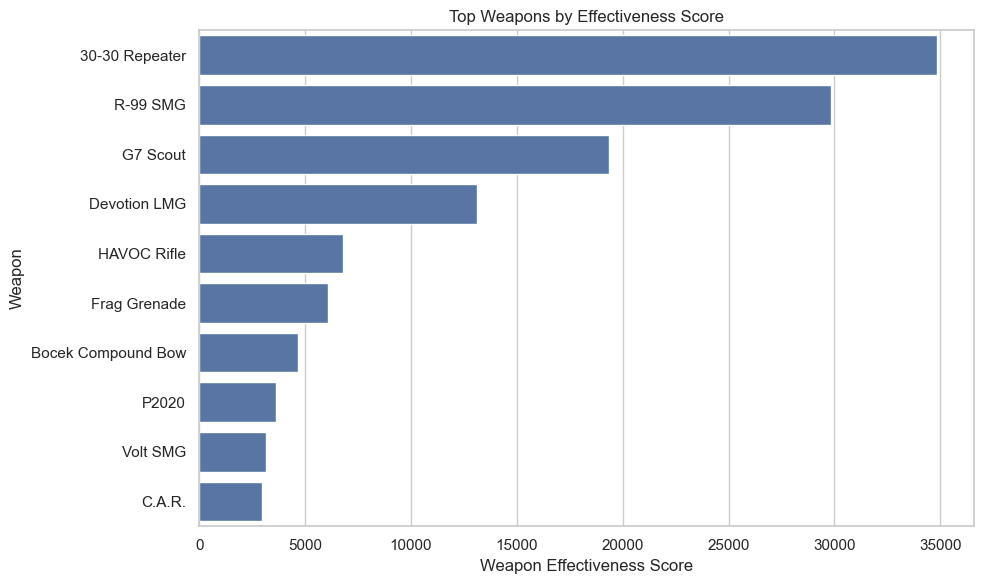

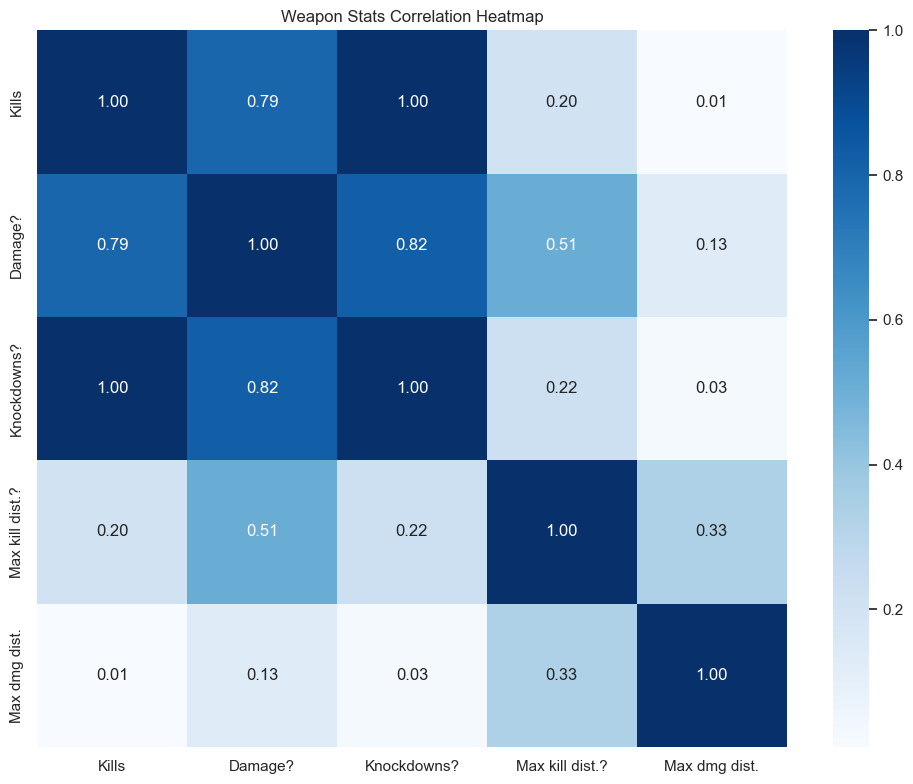

,Weapon,Kills,Damage?,Knockdowns?,FWR%?,Shots?,Hits?,Accuracy?,Playtime?,Max kill dist.?,Max dmg dist.,Weapon Effectiveness Score
2,30-30 Repeater,41,69570,96,68.57%,8144,1305,16.02%,17h 59m 46s,209.8,363.8,34850.00
0,R-99 SMG,157,59234,324,62.67%,18642,4847,26%,10h 27m 24s,48.7,147.8,29855.00
3,G7 Scout,38,38629,87,76.99%,9373,1139,12.15%,11h 3m 32s,288.0,351.3,19374.25
1,Devotion LMG,65,26041,135,65.53%,7090,1736,24.49%,3h 40m 5s,44.5,165.8,13119.25
4,HAVOC Rifle,36,13485,68,61.26%,3904,716,18.34%,4h 19m 35s,70.3,162.9,6795.50
6,Frag Grenade,23,12092,41,100%,-,249,-,0h 0m 0s,110.3,111.3,6079.25
11,Bocek Compound Bow,9,9275,18,75.00%,149,147,98.66%,3h 21m 38s,89.9,241.2,4651.00
5,P2020,26,7176,46,56.79%,1885,320,16.98%,2h 39m 36s,45.1,95.2,3625.50
7,Volt SMG,21,6272,38,61.29%,2495,416,16.67%,1h 32m 17s,56.9,58.3,3166.50
9,C.A.R.,11,5938,21,48.84%,3325,447,13.44%,1h 32m 20s,25.3,117.6,2985.25


In [19]:
top_weapons = weapons.sort_values("Weapon Effectiveness Score", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_weapons, x="Weapon Effectiveness Score", y=weapon_name_col)
plt.title("Top Weapons by Effectiveness Score")
plt.xlabel("Weapon Effectiveness Score")
plt.ylabel("Weapon")
plt.tight_layout()
plt.show()

if len(numeric_weapon_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(weapons[numeric_weapon_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
    plt.title("Weapon Stats Correlation Heatmap")
    plt.tight_layout()
    plt.show()

top_weapons

## Save outputs

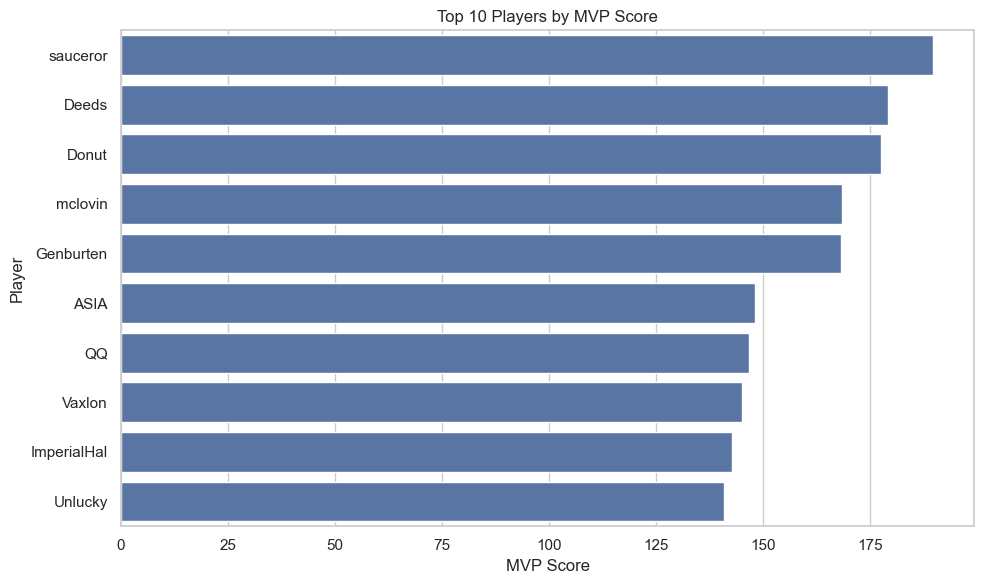

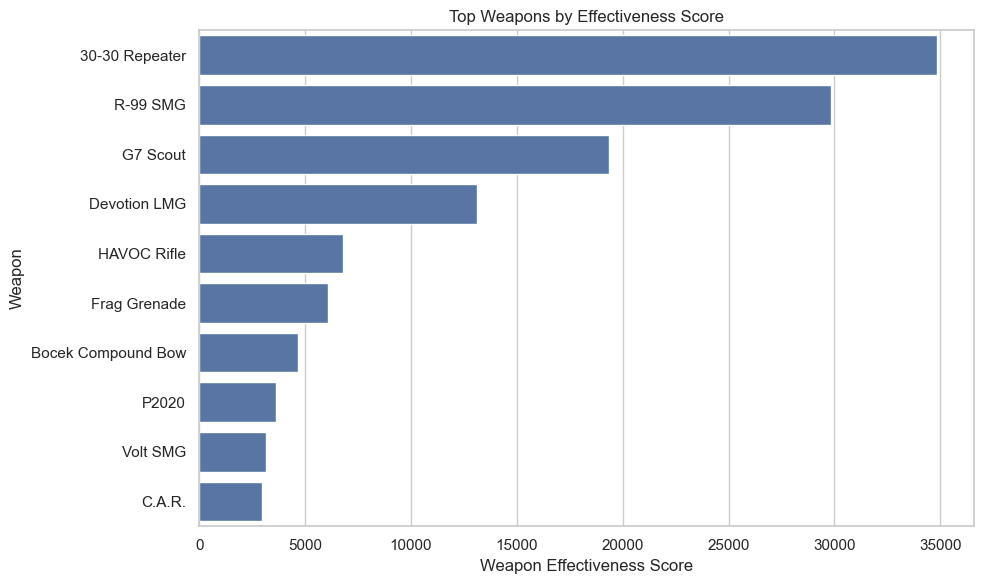

Saved cleaned outputs and charts.


In [20]:
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/charts", exist_ok=True)

df.to_csv("../outputs/cleaned_player_stats.csv", index=False)
team_summary.to_csv("../outputs/team_summary.csv", index=False)
top_players.to_csv("../outputs/top_players.csv", index=False)
weapons.to_csv("../outputs/cleaned_weapons.csv", index=False)
top_weapons.to_csv("../outputs/top_weapons.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_players, x="MVP Score", y="Player")
plt.title("Top 10 Players by MVP Score")
plt.xlabel("MVP Score")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig("../outputs/charts/top_players_mvp_score.png")
plt.show()

if weapon_name_col in top_weapons.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_weapons, x="Weapon Effectiveness Score", y=weapon_name_col)
    plt.title("Top Weapons by Effectiveness Score")
    plt.xlabel("Weapon Effectiveness Score")
    plt.ylabel("Weapon")
    plt.tight_layout()
    plt.savefig("../outputs/charts/top_weapons_effectiveness.png")
    plt.show()

print("Saved cleaned outputs and charts.")

## Key Findings

- Player impact is better measured with a combined score than with kills alone.
- Kills, K/D, damage differential, and team participation all contribute to strong player performance.
- Role classification helps separate aggressive fraggers from support-heavy players.
- Team performance can be compared by aggregating player-level output and average MVP score.
- Weapon effectiveness can be explored by ranking weapons using available summary metrics from the weapons dataset.
